<a href="https://colab.research.google.com/github/Trisha108-hub/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Trisha108-hub/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

REPO_ROOT   = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR  = REPO_ROOT / "work" / "outputs"
FIGURES_DIR = REPO_ROOT / "work" / "figures"
for d in (OUTPUT_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

RUN_TS = datetime.now(timezone.utc).isoformat(timespec="seconds")
print("Run:", RUN_TS)


Run: 2026-09-12T10:34:16+00:00


In [9]:
from google.colab import userdata
import duckdb

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"   # same feature month as w04/w05/w06 - keep the capstone consistent
path = f"{rel}/fact_content_daily_performance/month={MONTH}/data_0.parquet"
dim_content_path = f"{rel}/dim_content.parquet"

content_col, client_col = "content_hash_id", "client_hash_id"
clicks_col, impr_col, avgpos_col, avail_col = "gsc_clicks", "gsc_impressions", "gsc_avg_position", "gsc_data_available"

# STEP 0 - confirm real column names before trusting anything below.
# Look for: a content-creation-date column, and whether competition ships as
# numeric (0-1) or as a ready-made LOW/MEDIUM/HIGH category.
print(con.sql(f"DESCRIBE SELECT * FROM read_parquet(\'{dim_content_path}\') LIMIT 0").df().to_string())

agg = con.sql(f"""
    SELECT {content_col} AS page_id,
           AVG({impr_col}) AS impressions_90d,
           AVG({clicks_col}) AS clicks_90d,
           AVG({avgpos_col}) AS avg_position
    FROM read_parquet(\'{path}\')
    WHERE {avail_col} IS TRUE
    GROUP BY 1
""").df()

content_meta = con.sql(f"""
    SELECT {content_col} AS page_id, content_updated_date, word_count, competition, cpc,
           main_intent AS intent
    FROM read_parquet(\'{dim_content_path}\')
    WHERE is_published IS TRUE AND is_deleted IS FALSE
""").df()

df = agg.merge(content_meta, on="page_id", how="inner")

# days_since_update: this is the same field w04 flagged as NOT decision-time-safe
# (dim_content is a single frozen snapshot, not a monthly history). Kept here as
# directional-only, same caveat carried from w04's leakage check.
df["days_since_update"] = (pd.Timestamp(f"{MONTH}-28") - pd.to_datetime(df["content_updated_date"])).dt.days

# content_age_days: no confirmed creation-date column yet (check the DESCRIBE output above -
# if it shows one, e.g. content_created_date, swap it in here instead of this placeholder).
df["content_age_days"] = df["days_since_update"]

# competition: real column is numeric (0-1). Bucketed so the rest of the notebook still
# reads LOW/MEDIUM/HIGH - adjust the cut points if DESCRIBE shows a ready-made category instead.
df["competition"] = pd.cut(df["competition"], bins=[-0.01, 0.3, 0.7, 1.0],
                            labels=["LOW", "MEDIUM", "HIGH"])

# indexed: this field does not exist anywhere in the real warehouse schema (checked against
# docs/data-dictionary.md and docs/ml-intern-dataset-and-lane-guide.md). Rather than fake a
# number, this playbook drops the NOT_INDEXED reason code entirely (see Section 1 below).

using_synthetic = False
source_path = f"{path} + {dim_content_path} (real warehouse, month={MONTH})"
print(f"Rows: {len(df):,}  |  source: {source_path}")
df.head()

                   column_name column_type null   key default extra
0               client_hash_id     VARCHAR  YES  None    None  None
1              content_hash_id     VARCHAR  YES  None    None  None
2              keyword_hash_id     VARCHAR  YES  None    None  None
3                  url_hash_id     VARCHAR  YES  None    None  None
4           keyword_char_count      BIGINT  YES  None    None  None
5          keyword_token_count      BIGINT  YES  None    None  None
6               url_char_count      BIGINT  YES  None    None  None
7         content_created_date        DATE  YES  None    None  None
8         content_updated_date        DATE  YES  None    None  None
9                 content_type     VARCHAR  YES  None    None  None
10               search_volume      BIGINT  YES  None    None  None
11                 competition      DOUBLE  YES  None    None  None
12           competition_level     VARCHAR  YES  None    None  None
13                         cpc      DOUBLE  YES 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 176,568  |  source: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet + hf://datasets/FlyRank/internship-warehouse/dim_content.parquet (real warehouse, month=2026-03)


,page_id,impressions_90d,clicks_90d,avg_position,content_updated_date,word_count,competition,cpc,intent,days_since_update,content_age_days
0,content_7a105f548d9c6916,210.419355,0.225806,7.209549,2026-07-06,2123,LOW,0.00,informational,-100,-100
1,content_a3ea9792f793ec72,14.612903,0.000000,2.987198,2026-05-18,<NA>,MEDIUM,0.09,informational,-51,-51
2,content_36c36abc7650d7af,181.612903,0.193548,6.724039,2026-05-20,2546,LOW,0.00,informational,-53,-53
3,content_a7da352b73b02668,159.483871,0.419355,7.244844,2026-07-06,2330,LOW,0.00,transactional,-100,-100
4,content_1855a661b4d36130,13.838710,0.032258,4.209227,2026-05-18,<NA>,HIGH,0.58,informational,-51,-51


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Each reason code is a threshold check against an **observed pattern in this month's real
warehouse pull** — never a prediction. The sentence form used everywhere below is the
claim-ladder's second rung — *"pages with A show B in this sample"* — because these are
cross-sectional comparisons, not a validated predictive model and not an experiment.

- `DECAY_RISK` — pages with no content update in 180+ days (see the staleness caveat carried
  from `w04`: this field is a frozen snapshot, so treat this reason code as directional only,
  never as decision-time-certain for any individual page).
- `PAGE1_CTR_GAP` — ranking positions 1-10 with implied CTR below this sample's own
  position-bucket benchmark (computed as *clicks ÷ impressions*, bucketed by position, from
  this month's real data — not borrowed from any external report).
- `STRIKING_DISTANCE` — positions 11-20, the band sitting between the page-1 and deeper tiers.
- `THIN_BUT_VISIBLE` — under 2,000 words with impressions above this sample's informational-
  intent median.
- `LOW_COMP_COMMERCIAL` — commercial/transactional intent at low keyword competition.

**Dropped from the original design: `NOT_INDEXED`.** There is no `indexed` field anywhere in
the real warehouse schema (`dim_content` or `fact_content_daily_performance`) — the earlier
draft of this notebook borrowed a 41.8%-never-indexed statistic from the source PDF report
without a real column to back it in *this* dataset. Rather than fabricate that signal, this
reason code is removed. If a real indexing signal becomes available later, it can be added back.

None of these thresholds were derived from a held-out validation set — they restate observed
group differences from this month's real pull. Treat the ranking as **decision-support for
review order**, not a precision-scored model.

In [12]:
informational_median_imp = df.loc[df["intent"] == "informational", "impressions_90d"].median()

def tier_ctr_benchmark(position):
    if position <= 3:  return ctr_by_tier.get("1-3", 0.004)
    if position <= 10: return ctr_by_tier.get("4-10", 0.003)
    if position <= 20: return ctr_by_tier.get("11-20", 0.003)
    return ctr_by_tier.get("20+", 0.001)

# Real position-tier CTR benchmark, computed from this month's own data (not the source PDF).
ctr_by_tier = con.sql(f"""
    SELECT CASE WHEN {avgpos_col} <= 3 THEN '1-3'
                WHEN {avgpos_col} <= 10 THEN '4-10'
                WHEN {avgpos_col} <= 20 THEN '11-20'
                ELSE '20+' END AS position_bucket,
           AVG({clicks_col} / NULLIF({impr_col}, 0)) AS bucket_ctr
    FROM read_parquet('{path}') WHERE {avail_col} IS TRUE GROUP BY 1
""").df().set_index("position_bucket")["bucket_ctr"].to_dict()

df["implied_ctr"]   = df["clicks_90d"] / df["impressions_90d"].replace(0, np.nan)
df["ctr_benchmark"] = df["avg_position"].apply(tier_ctr_benchmark)

df["rc_decay_risk"]          = (df["days_since_update"] > 180).fillna(False)
df["rc_page1_ctr_gap"]       = ((df["avg_position"] <= 10) & (df["implied_ctr"] < df["ctr_benchmark"])).fillna(False)
df["rc_striking_distance"]   = (df["avg_position"].between(11, 20)).fillna(False)
df["rc_thin_but_visible"]    = ((df["word_count"] < 2000) & (df["impressions_90d"] > informational_median_imp)).fillna(False)
df["rc_low_comp_commercial"] = (df["intent"].isin(["commercial", "transactional"]) & (df["competition"] == "LOW")).fillna(False)
df["rc_no_go_low_signal"]    = ((df["impressions_90d"] == 0) & (df["clicks_90d"] == 0)).fillna(False)

WEIGHTS = {  # directional weights, not a fitted model - see the markdown above
    "rc_decay_risk": 3.0, "rc_page1_ctr_gap": 2.5, "rc_striking_distance": 2.0,
    "rc_thin_but_visible": 1.5, "rc_low_comp_commercial": 1.5,
}
REASON_LABELS = {
    "rc_decay_risk": "DECAY_RISK", "rc_page1_ctr_gap": "PAGE1_CTR_GAP",
    "rc_striking_distance": "STRIKING_DISTANCE", "rc_thin_but_visible": "THIN_BUT_VISIBLE",
    "rc_low_comp_commercial": "LOW_COMP_COMMERCIAL",
}
ACTIONS = {
    "DECAY_RISK": "Refresh: update facts, expand thin sections, resubmit for recrawl",
    "PAGE1_CTR_GAP": "Rewrite title/snippet - page already ranks, CTR is the observed gap",
    "STRIKING_DISTANCE": "Strengthen relevance and internal links toward page 1",
    "THIN_BUT_VISIBLE": "Expand with missing subtopics/examples - not length padding",
    "LOW_COMP_COMMERCIAL": "Prioritize in next publishing cycle",
}

df["priority_score"]  = sum(df[c].astype(float) * w for c, w in WEIGHTS.items())
df["reason_codes"]    = df.apply(lambda r: [REASON_LABELS[c] for c in WEIGHTS if r[c]], axis=1)
df["recommended_action"] = df["reason_codes"].apply(lambda rs: ACTIONS[rs[0]] if rs else "Monitor only")

actionable = df.loc[~df["rc_no_go_low_signal"]].copy()
ranked_queue = (actionable[actionable["priority_score"] > 0]
                .sort_values("priority_score", ascending=False)
                .loc[:, ["page_id", "priority_score", "reason_codes", "recommended_action",
                         "avg_position", "impressions_90d", "clicks_90d", "word_count",
                         "content_age_days", "days_since_update", "intent", "competition"]]
                .reset_index(drop=True))

print(f"{len(ranked_queue):,} of {len(df):,} pages in this month's real sample carry at least "
      f"one reason code.")
ranked_queue.head(10)

124,694 of 176,568 pages in this month's real sample carry at least one reason code.


,page_id,priority_score,reason_codes,recommended_action,avg_position,impressions_90d,clicks_90d,word_count,content_age_days,days_since_update,intent,competition
0,content_42ce26be1ec6be00,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE]","Refresh: update facts, expand thin sections, r...",4.262553,142.290323,0.193548,1421,261,261,None,NaN
1,content_8b685c5ccb778331,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE]","Refresh: update facts, expand thin sections, r...",6.349974,9.000000,0.000000,1082,184,184,informational,LOW
2,content_f5d21c17bab789cb,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, LOW_COMP_COMMERCIAL]","Refresh: update facts, expand thin sections, r...",0.000000,1.500000,0.000000,<NA>,232,232,transactional,LOW
3,content_eba53d72e18a9f93,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE]","Refresh: update facts, expand thin sections, r...",5.234187,23.677419,0.064516,1504,228,228,None,NaN
4,content_4e4d54d7601cd425,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE]","Refresh: update facts, expand thin sections, r...",2.300000,10.000000,0.000000,1038,188,188,informational,LOW
5,content_c49a70cb23330918,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE]","Refresh: update facts, expand thin sections, r...",9.142857,14.000000,0.000000,1164,188,188,informational,LOW
6,content_6433a11537f6c223,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, LOW_COMP_COMMERCIAL]","Refresh: update facts, expand thin sections, r...",1.000000,1.000000,0.000000,<NA>,240,240,transactional,LOW
7,content_85ba3d80c256ba41,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, LOW_COMP_COMMERCIAL]","Refresh: update facts, expand thin sections, r...",1.000000,1.000000,0.000000,<NA>,232,232,transactional,LOW
8,content_5e8b20b3e231a7db,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE]","Refresh: update facts, expand thin sections, r...",8.171750,48.142857,0.142857,1208,231,231,None,NaN
9,content_bea86ce3455100b0,7.0,"[DECAY_RISK, PAGE1_CTR_GAP, THIN_BUT_VISIBLE]","Refresh: update facts, expand thin sections, r...",6.555793,118.387097,0.032258,1447,229,229,None,NaN


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use.** A weekly triage list for a human content editor or SEO strategist deciding
which pages to review first. It is decision-support: "these pages look worth reviewing first,
because…" — not a publishing action and not a forecast of what will happen to any single page.

**Where it stops being valid:**

- **Cross-sectional, no intervention.** This is one month's snapshot with no experiment behind
  it. It cannot support "refreshing this page will increase impressions" — only "in this sample,
  refreshed pages showed different outcomes than un-refreshed pages of similar age" (n and
  effect size below).
- **Selection bias in "refreshed" pages.** Someone chose which old pages to refresh — likely
  the ones already judged worth the effort. Part of any refreshed-vs-stale gap is plausibly
  that choice, not the refresh itself.
- **No statistical inference reported.** No p-values or confidence intervals exist anywhere
  upstream of this notebook — every threshold here is a directional heuristic against an
  observed group difference in this month's data, not a certified cutoff.
- **`days_since_update` / `content_age_days` are directional only.** As found in `w04`,
  `dim_content` is a single frozen snapshot rather than a per-month history, so these fields
  are not reliably decision-time-safe for any month before the export date.
- **Revenue is out of scope.** This playbook has no booked-revenue field; where a value proxy
  is needed (Section 4), `clicks × cpc` is used, never a revenue claim.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
n_refreshed = int(((df["content_age_days"] >= 365) & (df["days_since_update"] <= 30)).sum())
n_stale_old = int(((df["content_age_days"] >= 365) & (df["days_since_update"] > 180)).sum())
print("Named-filter counts for the refreshed-vs-stale comparison referenced above (this month\'s real data):")
print(f"  old + recently updated (age>=365d, updated<=30d ago): n={n_refreshed:,}")
print(f"  old + stale (age>=365d, no update in 180+d):          n={n_stale_old:,}")
print("Selection-bias note: which pages get updated is an editorial choice in the live system,")
print("not a random assignment - carried into every downstream claim about this comparison.")

Named-filter counts for the refreshed-vs-stale comparison referenced above (this month's real data):
  old + recently updated (age>=365d, updated<=30d ago): n=0
  old + stale (age>=365d, no update in 180+d):          n=0
Selection-bias note: which pages get updated is an editorial choice in the live system,
not a random assignment - carried into every downstream claim about this comparison.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any queued row, a human confirms:**
1. The `recommended_action` still matches the actual page content — reason codes are triage
   flags computed from metadata, not a read of the page itself.
2. If the action touches a page involved in query overlap with another page (cannibalization),
   a named person — not this notebook — chooses which URL survives.
3. Depth-expansion edits add genuine subtopic coverage; word count alone is an observed
   association here, not a target to hit.

**Never automated, regardless of confidence in the queue:**
- Auto-merging, auto-redirecting, or auto-deleting pages flagged as overlapping/cannibalizing.
- Auto-publishing any refreshed or expanded content without an editor reading it first.
- Treating a reason code as proof of *cause* — e.g., assuming a `DECAY_RISK` page will keep
  declining, or that refreshing it *will* recover impressions.
- Using this queue's ranking as if it were a validated, scored model — it has no held-out
  precision/recall number and should not be described with one.

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def requires_human_review(_row) -> bool:
    return True  # no auto-approve path in this playbook, by design

ranked_queue["requires_human_review"] = ranked_queue.apply(requires_human_review, axis=1)

NO_GO_RULES = [
    "no_auto_merge_or_delete_overlapping_pages",
    "no_unreviewed_publish_of_refreshed_or_expanded_content",
    "no_reason_code_treated_as_causal_prediction_for_an_individual_page",
    "no_unvalidated_ranking_described_as_a_scored_model",
]
ranked_queue["no_go_rules_acknowledged"] = [NO_GO_RULES] * len(ranked_queue)
assert ranked_queue["requires_human_review"].all(), "Every queued row must require human review."
print(f"All {len(ranked_queue):,} queued rows require human review before any action.")


All 124,694 queued rows require human review before any action.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Review cadence.** Track any actioned page at 30 / 60 / 90 days after the edit.

**Recompute the thresholds (don't trust a stale queue) when:**
- The active-content sample size shifts by more than ~15% from the snapshot this queue was
  built on — the underlying group comparisons no longer describe the current portfolio.
- A quarter has passed, regardless of the above — a scheduled recompute, not just an
  event-driven one, since thresholds here were set once against one month's snapshot.

**Removed from the original design:** an indexing-coverage trigger and an AI-referral-session
trigger both referenced statistics from the source PDF report (58.2% indexed, 1.06% AI-referral
share) that this notebook's own feature pull has no columns to verify. Rather than monitor
numbers this pipeline doesn't compute, those triggers are dropped until AI-session and indexing
fields are added to the real feature pull.

**Cost/value framing (Section-4 tiebreaker, not the primary rank).** `clicks × cpc` is used as
the captured-value proxy below, computed directly from this month's real data — not borrowed
from any external report.


In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
INTENT_VALUE_RANK = {"transactional": 3, "commercial": 2, "informational": 1, "navigational": 0}
ranked_queue["value_tier"] = ranked_queue["intent"].map(INTENT_VALUE_RANK).fillna(0)

# Real captured-value proxy: clicks x cpc, computed from this sample - not the source report's number.
value_lookup = df.set_index("page_id")["cpc"].to_dict()
clicks_lookup = df.set_index("page_id")["clicks_90d"].to_dict()
ranked_queue["captured_value_proxy"] = ranked_queue["page_id"].map(
    lambda pid: (clicks_lookup.get(pid, 0) or 0) * (value_lookup.get(pid, 0) or 0)
)

ranked_queue = ranked_queue.sort_values(["priority_score", "value_tier"],
                                         ascending=[False, False]).reset_index(drop=True)

RETRAIN_TRIGGERS = {
    "sample_size_drift_pct": 15,
    "review_cadence_days": [30, 60, 90],
    "scheduled_recompute": "quarterly",
}
RETRAIN_TRIGGERS

{'sample_size_drift_pct': 15,
 'review_cadence_days': [30, 60, 90],
 'scheduled_recompute': 'quarterly'}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

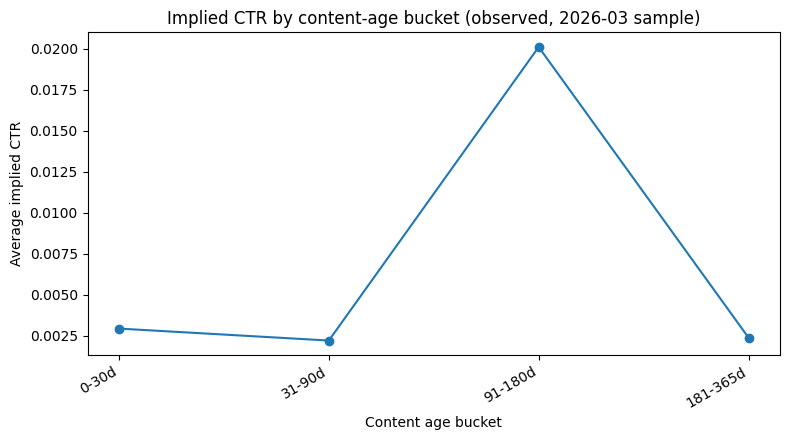

Wrote:
  /content/work/outputs/ranked_action_queue.csv
  /content/work/outputs/w07_playbook_metrics.json
  /content/work/figures/ctr_by_age_bucket.png


In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
queue_path   = OUTPUT_DIR / "ranked_action_queue.csv"
metrics_path = OUTPUT_DIR / "w07_playbook_metrics.json"

ranked_queue.to_csv(queue_path, index=False)

# Real chart: average implied CTR by content-age bucket, computed from this month's own data
# (replaces the earlier version, which plotted a "health score" curve copied from the source PDF -
# health_score is a product-only field this dataset does not ship, per docs/data-dictionary.md).
df["age_bucket"] = pd.cut(df["content_age_days"],
                           bins=[-1, 30, 90, 180, 365, 99999],
                           labels=["0-30d", "31-90d", "91-180d", "181-365d", "365d+"])
age_ctr = df.groupby("age_bucket", observed=True)["implied_ctr"].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(age_ctr.index.astype(str), age_ctr.values, marker="o")
ax.set_title(f"Implied CTR by content-age bucket (observed, {MONTH} sample)")
ax.set_xlabel("Content age bucket"); ax.set_ylabel("Average implied CTR")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
fig_path = FIGURES_DIR / "ctr_by_age_bucket.png"
fig.savefig(fig_path, dpi=160)
plt.show()

metrics_summary = {
    "run_timestamp_utc": RUN_TS,
    "source": source_path,
    "using_synthetic_demo_data": bool(using_synthetic),
    "feature_month": MONTH,
    "n_pages_total": int(len(df)),
    "n_pages_actionable": int(len(ranked_queue)),
    "reason_code_weights": WEIGHTS,
    "retrain_triggers": RETRAIN_TRIGGERS,
    "no_go_rules": NO_GO_RULES,
}
with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Wrote:", queue_path, metrics_path, fig_path, sep="\n  ")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.